In [ ]:
"""
WC-VC（Weighted Cascade Viral Centrality）計算スクリプト
=========================================================
network.txt の元ノードID（9090999...等）を 0-based index に変換し、
WC モデルで P 行列を構築して v = (I-P)^{-1} · 1 を解く。

使い方:
    python wc_vc.py network.txt

network.txt の形式:
    <from_id> <to_id>   （1行1エッジ、空白区切り）
    例: 9090999 3847291
"""

import sys
import time
import numpy as np
import networkx as nx
from scipy.sparse import lil_matrix, csr_matrix, eye
from scipy.sparse.linalg import spsolve, eigs


# ─────────────────────────────────────────────
# 対象 IP（内部 index）
# ─────────────────────────────────────────────
IP_INDICES = [38598, 28025, 9199, 27638, 12605,
              69023, 79973, 68985, 51867, 33649]


def load_graph_and_mapping(txt_path: str):
    """
    network.txt を読み込み、元IDを 0-based index に変換した
    有向グラフと対応表を返す。

    graph_lib の変換順序を再現するために「登場順（insertion order）」
    でインデックスを付与する。もし graph_lib が昇順ソートなら
    sort_ids=True に変更すること。

    Returns
    -------
    G       : nx.DiGraph  （ノード番号 = 0-based index）
    orig_ids: list         （index → 元ID の逆引きリスト）
    id_map  : dict         （元ID → index の正引き辞書）
    """
    print(f"[1] Reading {txt_path} ...")
    t0 = time.time()

    raw_edges = []
    seen = {}          # 元ID → index （登場順）

    def get_idx(orig_id):
        if orig_id not in seen:
            seen[orig_id] = len(seen)
        return seen[orig_id]

    with open(txt_path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            u_orig, v_orig = int(parts[0]), int(parts[1])
            u_idx = get_idx(u_orig)
            v_idx = get_idx(v_orig)
            raw_edges.append((v_idx, u_idx))

    # 逆引きリスト（index → 元ID）
    orig_ids = [None] * len(seen)
    for orig_id, idx in seen.items():
        orig_ids[idx] = orig_id

    G = nx.DiGraph()
    G.add_nodes_from(range(len(seen)))
    G.add_edges_from(raw_edges)

    print(f"    ノード数: {G.number_of_nodes():,}")
    print(f"    エッジ数: {G.number_of_edges():,}")
    print(f"    所要時間: {time.time()-t0:.1f}s")
    return G, orig_ids, seen


def show_ip_mapping(ip_indices, orig_ids):
    """IP の内部 index と元ID の対応を表示"""
    print("\n[2] IP の index ↔ 元ID 対応")
    print(f"    {'内部 index':>12}  {'元ID':>15}")
    print("    " + "-" * 30)
    for idx in ip_indices:
        if idx < len(orig_ids):
            print(f"    {idx:>12}  {orig_ids[idx]:>15}")
        else:
            print(f"    {idx:>12}  {'範囲外':>15}")


def build_wc_matrix(G: nx.DiGraph) -> csr_matrix:
    """
    WC モデルの疎行列 P を構築する。

    WC の定義:  p_{u→v} = 1 / d_in(v)
    行列表現:   P[v, u] = 1 / d_in(v)  （v が被影響ノード、u が影響元）

    つまり P の列和 = 1（各入次数で正規化済み）。
    """
    print("\n[3] WC 行列を構築中 ...")
    t0 = time.time()
    n = G.number_of_nodes()

    # lil_matrix は行方向の書き込みが速い
    P = lil_matrix((n, n), dtype=np.float64)

    for v in G.nodes():
        d_in = G.in_degree(v)
        if d_in == 0:
            continue
        weight = 0.5 / d_in
        for u in G.predecessors(v):
            P[v, u] = weight   # P[被影響, 影響元]

    P_csr = P.tocsr()
    print(f"    非ゼロ要素数: {P_csr.nnz:,}")
    print(f"    所要時間: {time.time()-t0:.1f}s")
    return P_csr


def check_convergence(P_csr: csr_matrix) -> float:
    """
    最大固有値 |λ|_max を計算し収束条件を確認。
    (I-P)^{-1} の収束には |λ|_max < 1 が必要。
    """
    print("\n[4] 収束条件の確認（最大固有値）...")
    try:
        vals, _ = eigs(P_csr.astype(complex), k=1, which='LM', maxiter=5000)
        lam_max = float(np.max(np.abs(vals)))
        status = "✓ 収束（VC 計算可能）" if lam_max < 1.0 else "✗ 発散（要注意）"
        print(f"    |λ|_max = {lam_max:.6f}  {status}")
        return lam_max
    except Exception as e:
        print(f"    固有値計算エラー（スキップ）: {e}")
        return -1.0


def compute_vc_for_ips(P_csr: csr_matrix, ip_indices: list) -> dict:
    """
    指定した IP ノードについて VC を計算する。

    v = (I - P)^{-1} · 1  を解くのではなく、
    各 IP i について e_i^T (I - P)^{-T} · 1 = VC(i) を求める。

    = (I - P^T) x = e_i  を解いて x の和を取る方法が効率的。

    または列 i だけ必要なら:
        (I - P) v = e_i  →  v = (I-P)^{-1} e_i
        VC(i) = sum(v) - 1   ← i 自身を除く

    ここでは後者の方法を使う（IP は10個のみ）。
    """
    print(f"\n[5] VC を計算中（{len(ip_indices)} 個の IP）...")
    n = P_csr.shape[0]
    I_minus_P = eye(n, format='csr') - P_csr
    results = {}

    for ip in ip_indices:
        if ip >= n:
            print(f"    IP {ip}: 範囲外（スキップ）")
            continue
        t0 = time.time()

        # e_ip: ip 番目だけ 1 の単位ベクトル
        e_ip = np.zeros(n)
        e_ip[ip] = 1.0

        # (I - P) · v = e_ip  を解く
        # v[j] = "ip から j への到達に関わる期待値の寄与"
        v = spsolve(I_minus_P, e_ip)

        # VC = v の全和 - 1（ip 自身を除く）
        vc = float(v.sum()) - 1.0
        elapsed = time.time() - t0
        results[ip] = vc
        print(f"    IP {ip:>6}: VC = {vc:>12.2f}  ({elapsed:.2f}s)")

    return results


def compare_with_xlsx(vc_results: dict, orig_ids: list):
    """
    WC-VC と xlsx の実測値（全体像）を並べて表示する。
    xlsx の値は直接入力（実際の分析では CSV 読み込みに変更可）。
    """
    # xlsx から取得した全体 msg 外部行動者数（実測 VC_X）
    xlsx_vc_x = {
        38598: 4948.19, 28025: 1470.74, 9199:  100.00,
        27638:   67.98, 12605:   11.52, 69023:  47.24,
        79973:   11.12, 68985:    4.28, 51867:   7.67,
        33649:    0.34,
    }

    print("\n[6] WC-VC vs 実測 VC_X（外部行動者数）比較")
    print(f"    {'IP':>8}  {'元ID':>15}  {'WC-VC':>12}  {'実測VC_X':>12}  {'比率':>8}")
    print("    " + "-" * 65)

    for ip in sorted(vc_results.keys(), key=lambda x: -vc_results[x]):
        orig = orig_ids[ip] if ip < len(orig_ids) else "?"
        wc   = vc_results[ip]
        real = xlsx_vc_x.get(ip, float('nan'))
        ratio = wc / real if real > 0 else float('nan')
        print(f"    {ip:>8}  {orig:>15}  {wc:>12.2f}  {real:>12.2f}  {ratio:>8.3f}")

    # Spearman 相関
    from scipy.stats import spearmanr
    ips_common = [ip for ip in vc_results if ip in xlsx_vc_x]
    if len(ips_common) >= 3:
        wc_vals   = [vc_results[ip] for ip in ips_common]
        real_vals = [xlsx_vc_x[ip]  for ip in ips_common]
        rho, pval = spearmanr(wc_vals, real_vals)
        print(f"\n    Spearman 相関係数 ρ = {rho:.4f}  (p = {pval:.4f})")
        if abs(rho) > 0.7:
            print("    → WC-VC は実測 VC_X の良い代理変数")
        elif abs(rho) > 0.4:
            print("    → 中程度の相関（他の指標との組み合わせを検討）")
        else:
            print("    → 相関が低い（動的要因が支配的）")


# ─────────────────────────────────────────────
# メイン
# ─────────────────────────────────────────────
def main():
    txt_path = "/Users/hongseokyeong/Desktop/diffusion_seokyeong/test/twitter_dataset.txt"
    G, orig_ids, id_map = load_graph_and_mapping(txt_path)
    show_ip_mapping(IP_INDICES, orig_ids)

    P_csr = build_wc_matrix(G)
    lam   = check_convergence(P_csr)

    if lam >= 1.0:
        print("\n  ⚠ |λ|_max >= 1 のため (I-P)^{-1} が収束しない可能性があります。")
        print("    p スケーリング（P = P * 0.5 など）を検討してください。")
        # オプション：p=0.5 をかけて収束させる
        # P_csr = P_csr * 0.5

    vc_results = compute_vc_for_ips(P_csr, IP_INDICES)
    compare_with_xlsx(vc_results, orig_ids)

    # 結果を CSV に保存
    import csv
    out_path = "wc_vc_results.csv"
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ip_index", "orig_id", "wc_vc"])
        for ip, vc in vc_results.items():
            orig = orig_ids[ip] if ip < len(orig_ids) else ""
            writer.writerow([ip, orig, round(vc, 4)])
    print(f"\n[7] 結果を {out_path} に保存しました。")


if __name__ == "__main__":
    main()

[1] Reading /Users/hongseokyeong/Desktop/diffusion_seokyeong/test/twitter_dataset.txt ...
    ノード数: 81,306
    エッジ数: 1,768,149
    所要時間: 2.7s

[2] IP の index ↔ 元ID 対応
        内部 index              元ID
    ------------------------------
           38598         17756596
           28025         29406557
            9199         14348594
           27638         71271236
           12605         18030840
           69023          6604072
           79973        177046670
           68985         44682842
           51867        178593058
           33649         60443269

[3] WC 行列を構築中 ...
    非ゼロ要素数: 1,768,149
    所要時間: 1.7s

[4] 収束条件の確認（最大固有値）...
    |λ|_max = 1.000000  ✗ 発散（要注意）

  ⚠ |λ|_max >= 1 のため (I-P)^{-1} が収束しない可能性があります。
    p スケーリング（P = P * 0.5 など）を検討してください。

[5] VC を計算中（10 個の IP）...


ノード数: 100
エッジ数: 149
平均入次数: 1.49
平均出次数: 1.49
弱連結成分数: 1
DAG?: False


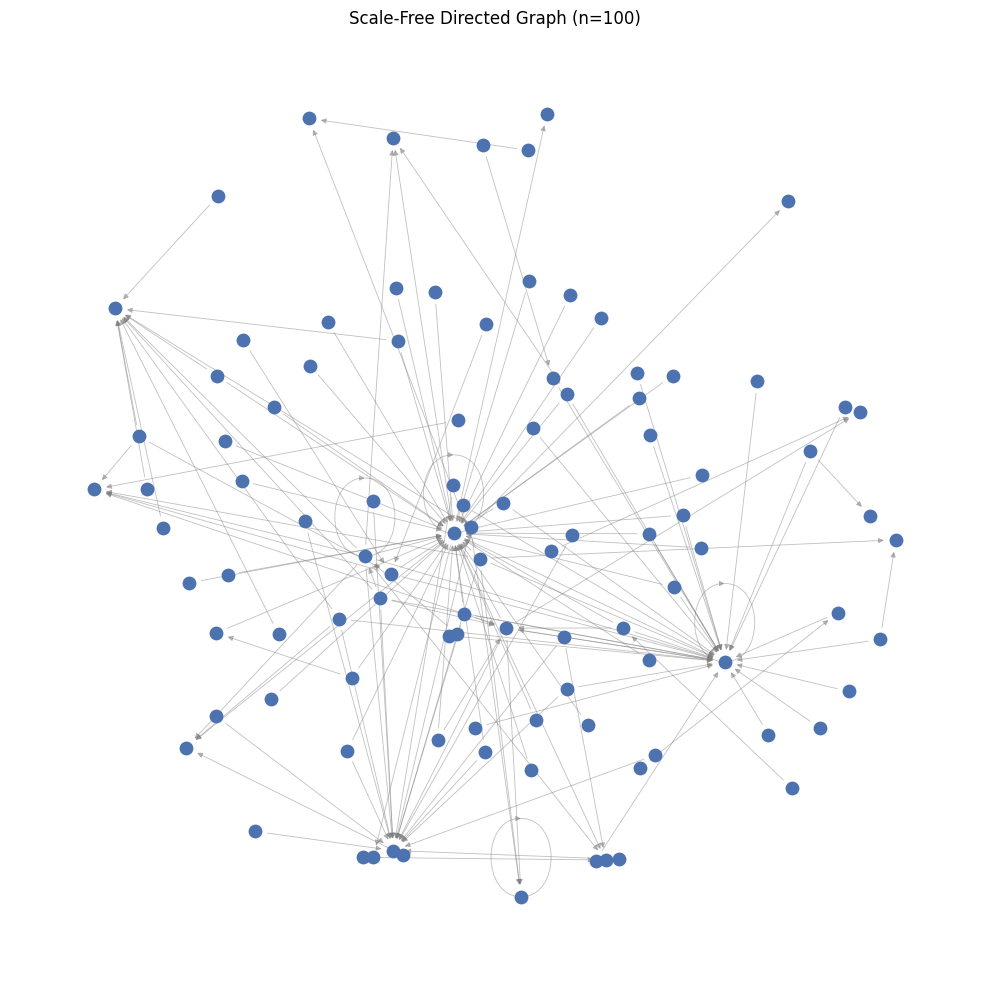

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random

N = 100  # ノード数

def generate_digraph(model="scale_free", n=100, seed=42):
    """
    100ノード規模の有向グラフを生成する
    
    model:
      - "erdos_renyi" : ランダム(各エッジが確率pで存在)
      - "scale_free"  : スケールフリー(べき則分布、現実のネットワークに近い)
      - "small_world" : スモールワールド(有向版)
      - "random_dag" : ランダムな有向非巡回グラフ(DAG)
    """
    random.seed(seed)
    
    if model == "erdos_renyi":
        # p=0.05 → 平均出次数 ≈ 5
        G = nx.gnp_random_graph(n, p=0.05, directed=True, seed=seed)
    
    elif model == "scale_free":
        # Barabási–Albert型の有向版。SNS・Web等の構造に類似
        G = nx.scale_free_graph(n, seed=seed)
        G = nx.DiGraph(G)  # MultiDiGraph → DiGraph に変換(重複エッジ削除)
    
    elif model == "small_world":
        # 無向のWatts-Strogatzを生成して有向化
        base = nx.watts_strogatz_graph(n, k=6, p=0.1, seed=seed)
        G = nx.DiGraph()
        for u, v in base.edges():
            # 各エッジをランダムな向きで追加(時々双方向)
            if random.random() < 0.3:
                G.add_edge(u, v); G.add_edge(v, u)
            elif random.random() < 0.5:
                G.add_edge(u, v)
            else:
                G.add_edge(v, u)
    
    elif model == "random_dag":
        # トポロジカル順序を固定してエッジを張る
        G = nx.DiGraph()
        G.add_nodes_from(range(n))
        for i in range(n):
            for j in range(i + 1, n):
                if random.random() < 0.05:
                    G.add_edge(i, j)
    
    else:
        raise ValueError(f"unknown model: {model}")
    
    return G


def summarize(G):
    print(f"ノード数: {G.number_of_nodes()}")
    print(f"エッジ数: {G.number_of_edges()}")
    print(f"平均入次数: {sum(d for _, d in G.in_degree())  / G.number_of_nodes():.2f}")
    print(f"平均出次数: {sum(d for _, d in G.out_degree()) / G.number_of_nodes():.2f}")
    print(f"弱連結成分数: {nx.number_weakly_connected_components(G)}")
    print(f"DAG?: {nx.is_directed_acyclic_graph(G)}")


def draw(G, title="Directed Graph"):
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, seed=42, k=0.5)
    nx.draw_networkx_nodes(G, pos, node_size=80, node_color="#4C72B0")
    nx.draw_networkx_edges(
        G, pos, arrows=True, arrowsize=8,
        edge_color="gray", alpha=0.5, width=0.6,
    )
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    G = generate_digraph(model="scale_free", n=N)
    summarize(G)
    nx.write_edgelist(G, "digraph_100.txt", data=False)
    draw(G, title=f"Scale-Free Directed Graph (n={N})")

    # 保存例
    # nx.write_graphml(G, "digraph_100.graphml")
    # nx.write_edgelist(G, "digraph_100.edgelist", data=False)

In [6]:
"""
全ノードの構造的中心性指標を計算するスクリプト
================================================
計算する指標:
  - 次数中心性 (in/out-degree centrality)
  - 媒介中心性 (betweenness centrality)
  - k-shell 分解 (core number)
  - PageRank
  - Katz 中心性

出力 CSV を wc_vc_all.py の結果と結合すれば
バイラル中心性との相関分析が可能になる。
"""

import sys
import time
import csv
import numpy as np
import networkx as nx


def compute_all_centralities(
    txt_path: str,
    reverse_edges: bool = True,
    output_csv: str = "centralities_all_nodes.csv",
):
    """
    Parameters
    ----------
    txt_path     : エッジリスト txt ファイル
    reverse_edges: True なら拡散方向に逆転（Twitter のフォロー→拡散）
    output_csv   : 結果出力ファイル
    """

    # ── 1. グラフ読み込み（登場順で 0-based index に変換） ──
    print(f"[1/4] Reading {txt_path} ...")
    t0 = time.time()

    raw_edges = []
    seen = {}

    def get_idx(orig_id):
        if orig_id not in seen:
            seen[orig_id] = len(seen)
        return seen[orig_id]

    with open(txt_path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            u_orig, v_orig = int(parts[0]), int(parts[1])
            u_idx, v_idx = get_idx(u_orig), get_idx(v_orig)
            if reverse_edges:
                raw_edges.append((v_idx, u_idx))
            else:
                raw_edges.append((u_idx, v_idx))

    orig_ids = [None] * len(seen)
    for orig_id, idx in seen.items():
        orig_ids[idx] = orig_id

    n = len(seen)

    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    G.add_edges_from(raw_edges)

    print(f"    nodes: {n:,}, edges: {G.number_of_edges():,}  "
          f"({time.time()-t0:.2f}s)")

    # ── 2. 中心性指標を計算 ──
    print(f"\n[2/4] Computing centralities ...")
    results = {}

    # 2-1. 次数中心性
    print("    - degree centralities ...", end=" ")
    t0 = time.time()
    results["in_degree"]      = dict(G.in_degree())
    results["out_degree"]     = dict(G.out_degree())
    results["in_degree_cent"] = nx.in_degree_centrality(G)
    results["out_degree_cent"]= nx.out_degree_centrality(G)
    print(f"({time.time()-t0:.2f}s)")

    # 2-2. 媒介中心性（O(n*m) なので 100 ノードなら一瞬）
    print("    - betweenness centrality ...", end=" ")
    t0 = time.time()
    results["betweenness"] = nx.betweenness_centrality(G, normalized=True)
    print(f"({time.time()-t0:.2f}s)")

    # 2-3. k-shell 分解（無向化して計算）
    print("    - k-shell decomposition ...", end=" ")
    t0 = time.time()
    G_undirected = G.to_undirected()
    # 自己ループがあると core_number でエラーになるので除去
    G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))
    results["k_shell"] = nx.core_number(G_undirected)
    print(f"({time.time()-t0:.2f}s)")

    # 2-4. PageRank
    print("    - PageRank ...", end=" ")
    t0 = time.time()
    results["pagerank"] = nx.pagerank(G, alpha=0.85, max_iter=200)
    print(f"({time.time()-t0:.2f}s)")

    # 2-5. Katz 中心性
    # α は 1/|λ|_max より小さく設定する必要がある
    print("    - Katz centrality ...", end=" ")
    t0 = time.time()
    try:
        # 最大固有値から α を自動決定
        A = nx.to_scipy_sparse_array(G, dtype=float)
        from scipy.sparse.linalg import eigs
        vals, _ = eigs(A, k=1, which='LM', maxiter=5000)
        lam_max = float(np.max(np.abs(vals)))
        alpha = 0.9 / lam_max if lam_max > 0 else 0.1
        results["katz"] = nx.katz_centrality_numpy(G, alpha=alpha)
        print(f"(α={alpha:.4f}, {time.time()-t0:.2f}s)")
    except Exception as e:
        print(f"failed ({e}); using power iteration ...", end=" ")
        try:
            results["katz"] = nx.katz_centrality(G, alpha=0.005, max_iter=2000)
            print(f"({time.time()-t0:.2f}s)")
        except Exception as e2:
            print(f"Katz failed: {e2}")
            results["katz"] = {i: float('nan') for i in range(n)}

    # ── 3. 統計サマリ ──
    print(f"\n[3/4] Summary statistics:")
    for key in ["in_degree", "out_degree", "betweenness", "k_shell",
                "pagerank", "katz"]:
        vals = list(results[key].values())
        v = np.array(vals, dtype=float)
        print(f"    {key:>20}: mean={v.mean():.4f}, max={v.max():.4f}, "
              f"min={v.min():.4f}")

    # ── 4. CSV 出力 ──
    print(f"\n[4/4] Writing {output_csv} ...")
    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "index", "orig_id",
            "in_degree", "out_degree",
            "in_degree_cent", "out_degree_cent",
            "betweenness", "k_shell",
            "pagerank", "katz",
        ])
        for i in range(n):
            writer.writerow([
                i, orig_ids[i],
                results["in_degree"][i],
                results["out_degree"][i],
                round(results["in_degree_cent"][i], 6),
                round(results["out_degree_cent"][i], 6),
                round(results["betweenness"][i], 6),
                results["k_shell"][i],
                round(results["pagerank"][i], 6),
                round(float(results["katz"][i]), 6),
            ])
    print(f"    saved {n:,} rows")

    # ── 各指標のトップ5を表示 ──
    print(f"\n=== Top 5 nodes by each centrality ===")
    metrics = ["out_degree", "betweenness", "k_shell", "pagerank", "katz"]
    for m in metrics:
        items = sorted(results[m].items(), key=lambda x: -x[1])[:5]
        print(f"\n  [{m}]")
        for r, (i, v) in enumerate(items, 1):
            print(f"    {r}. index={i:>4}  orig_id={orig_ids[i]:>12}  value={v:>10.4f}")

    return results, orig_ids


if __name__ == "__main__":
    # Notebook では sys.argv が使えないので直接パスを指定する
    txt_path = "digraph_100.txt"
    if len(sys.argv) > 1 and not sys.argv[1].startswith("--f="):
        txt_path = sys.argv[1]

    results, orig_ids = compute_all_centralities(
        txt_path=txt_path,
        reverse_edges=False,           # 拡散方向に逆転
        output_csv="centralities_all_nodes.csv",
    )

[1/4] Reading digraph_100.txt ...
    nodes: 100, edges: 149  (0.00s)

[2/4] Computing centralities ...
    - degree centralities ... (0.00s)
    - betweenness centrality ... (0.00s)
    - k-shell decomposition ... (0.00s)
    - PageRank ... (0.02s)
    - Katz centrality ... (α=0.4500, 0.02s)

[3/4] Summary statistics:
               in_degree: mean=1.4900, max=41.0000, min=0.0000
              out_degree: mean=1.4900, max=9.0000, min=0.0000
             betweenness: mean=0.0014, max=0.0504, min=0.0000
                 k_shell: mean=1.6100, max=4.0000, min=1.0000
                pagerank: mean=0.0100, max=0.1636, min=0.0035
                    katz: mean=0.0335, max=0.6682, min=0.0034

[4/4] Writing centralities_all_nodes.csv ...
    saved 100 rows

=== Top 5 nodes by each centrality ===

  [out_degree]
    1. index=  14  orig_id=           5  value=    9.0000
    2. index=   0  orig_id=           0  value=    7.0000
    3. index=  17  orig_id=           7  value=    7.0000
    4. inde

全ノードのVC

In [8]:
"""
全ノードの WC バイラル中心性を計算するスクリプト
=================================================
WC モデル:  p_{u→v} = p x (1 / d_in(v))
バイラル中心性: VC(j) = Σ_i (I-P)^{-1}_{i,j}  - 1

全ノード分を1回の線形システム解で求める:
    (I - P^T) · v = 1   →   v_j = VC(j) + 1
"""

import sys
import time
import csv
import numpy as np
from scipy.sparse import lil_matrix, eye
from scipy.sparse.linalg import spsolve, eigs


def compute_all_viral_centrality(
    txt_path: str,
    reverse_edges: bool = True,
    p_scale: float = 0.5,
    output_csv: str = "vc_all_nodes.csv",
):
    """
    Parameters
    ----------
    txt_path     : エッジリスト txt ファイル（1行 "from_id to_id"）
    reverse_edges: True なら txt のエッジを逆転（Twitter のフォロー→拡散方向）
    p_scale      : 受信確率 p（収束のため通常 0.5、|λ|_max ≥ 1 なら自動再スケール）
    output_csv   : 結果出力ファイル
    """

    # ── 1. グラフ読み込み（登場順で 0-based index に変換） ──
    print(f"[1/6] Reading {txt_path} ...")
    t0 = time.time()

    raw_edges = []
    seen = {}

    def get_idx(orig_id):
        if orig_id not in seen:
            seen[orig_id] = len(seen)
        return seen[orig_id]

    with open(txt_path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            u_orig, v_orig = int(parts[0]), int(parts[1])
            u_idx, v_idx = get_idx(u_orig), get_idx(v_orig)
            if reverse_edges:
                raw_edges.append((v_idx, u_idx))   # 拡散方向に逆転
            else:
                raw_edges.append((u_idx, v_idx))

    orig_ids = [None] * len(seen)
    for orig_id, idx in seen.items():
        orig_ids[idx] = orig_id

    n = len(seen)
    print(f"    nodes: {n:,}, edges: {len(raw_edges):,}  ({time.time()-t0:.1f}s)")

    # ── 2. 入次数と出次数の計算 ──
    print(f"\n[2/6] Computing degrees ...")
    in_degree  = np.zeros(n, dtype=np.int64)
    out_degree = np.zeros(n, dtype=np.int64)
    for u, v in raw_edges:
        in_degree[v]  += 1
        out_degree[u] += 1

    # ── 3. WC 行列を構築（P[v,u] = p / d_in(v)） ──
    print(f"\n[3/6] Building WC matrix ...")
    t0 = time.time()
    P = lil_matrix((n, n), dtype=np.float64)
    for u, v in raw_edges:
        if in_degree[v] > 0:
            P[v, u] = p_scale / in_degree[v]
    P_csr = P.tocsr()
    print(f"    nnz: {P_csr.nnz:,}  ({time.time()-t0:.1f}s)")

    # ── 4. 収束条件チェックと自動スケーリング ──
    print(f"\n[4/6] Checking |λ|_max ...")
    try:
        vals, _ = eigs(P_csr.astype(complex), k=1, which='LM', maxiter=5000)
        lam_max = float(np.max(np.abs(vals)))
        print(f"    |λ|_max = {lam_max:.4f}")
        if lam_max >= 1.0:
            alpha = 0.99 / lam_max
            P_csr = P_csr * alpha
            print(f"    → α = {alpha:.4f} で再スケーリング（|λ|_max → {lam_max*alpha:.4f}）")
    except Exception as e:
        print(f"    skip eigenvalue check: {e}")

    # ── 5. 全ノードの VC を一括計算 ──
    # (I - P^T) v = 1 を解くと v_j = Σ_i (I-P)^{-1}_{i,j} = VC(j) + 1
    print(f"\n[5/6] Solving (I - P^T) · v = 1 ...")
    t0 = time.time()
    I_minus_PT = eye(n, format='csr') - P_csr.T
    v = spsolve(I_minus_PT, np.ones(n))
    vc = v - 1.0   # 自身を除く
    print(f"    solved in {time.time()-t0:.1f}s")
    print(f"    VC: mean={vc.mean():.2f}, max={vc.max():.2f}, min={vc.min():.2f}")

    # ── 6. CSV 出力 ──
    print(f"\n[6/6] Writing {output_csv} ...")
    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["index", "orig_id", "wc_vc"])
        for i in range(n):
            writer.writerow([
                i, orig_ids[i], round(float(vc[i]), 6)
            ])
    print(f"    saved {n:,} rows")

    # ── 上位ノードを表示 ──
    print(f"\n=== Top 15 nodes by WC-VC ===")
    top = np.argsort(-vc)[:15]
    print(f"{'rank':>4}  {'index':>8}  {'orig_id':>15}  {'in_deg':>8}  {'out_deg':>8}  {'WC-VC':>14}")
    print("-" * 70)
    for r, i in enumerate(top, 1):
        print(f"{r:>4}  {i:>8}  {orig_ids[i]:>15}  "
              f"{in_degree[i]:>8}  {out_degree[i]:>8}  {vc[i]:>14.4f}")

    return vc, orig_ids


if __name__ == "__main__":
    # Notebook では sys.argv が使えないので直接パスを指定する
    txt_path = "/Users/hongseokyeong/Desktop/diffusion_seokyeong/analysis/digraph_100.txt"
    if len(sys.argv) > 1 and not sys.argv[1].startswith("--f="):
        txt_path = sys.argv[1]

    vc, orig_ids = compute_all_viral_centrality(
        txt_path=txt_path,
        reverse_edges=True,    # Twitter のフォロー方向を拡散方向に変換
        p_scale=0.5,           # 受信確率
        output_csv="vc_all_nodes.csv",
    )

[1/6] Reading /Users/hongseokyeong/Desktop/diffusion_seokyeong/analysis/digraph_100.txt ...
    nodes: 100, edges: 149  (0.0s)

[2/6] Computing degrees ...

[3/6] Building WC matrix ...
    nnz: 149  (0.0s)

[4/6] Checking |λ|_max ...
    |λ|_max = 0.5000

[5/6] Solving (I - P^T) · v = 1 ...
    solved in 0.0s
    VC: mean=0.66, max=16.75, min=0.00

[6/6] Writing vc_all_nodes.csv ...
    saved 100 rows

=== Top 15 nodes by WC-VC ===
rank     index          orig_id    in_deg   out_deg           WC-VC
----------------------------------------------------------------------
   1         1                1         2        32         16.7483
   2         0                0         7        41         16.5612
   3        10                9         0        19          6.1291
   4         7                2         6         5          5.1621
   5        15               36         0        11          3.0858
   6         8               14         1         4          2.3699
   7         2  

指定のノードVC

In [ ]:
"""
特定インデックスノードの WC バイラル中心性を計算するスクリプト
==================================================================
WC モデル:  p_{u→v} = p × (1 / d_in(v))
バイラル中心性: VC(j) = Σ_i (I-P)^{-1}_{i,j}  - 1

【元スクリプト wc_vc_all.py からの変更点】
  ★変更1: target_indices パラメータを追加（特定ノードだけ計算）
  ★変更2: 全ノード一括 (I-P^T)v=1 から、各 IP 個別 (I-P)v=e_i に変更
  ★変更3: CSV 出力を対象ノードのみに限定
  ★変更4: 結果表示も対象ノードのみ
"""

import sys
import time
import csv
import numpy as np
from scipy.sparse import lil_matrix, eye
from scipy.sparse.linalg import spsolve, eigs


def compute_target_viral_centrality(
    txt_path: str,
    target_indices: list,        # ★変更1: 計算対象のインデックスリスト
    reverse_edges: bool = True,
    p_scale: float = 0.5,
    output_csv: str = "vc_targets.csv",
):
    """
    Parameters
    ----------
    txt_path       : エッジリスト txt ファイル
    target_indices : 計算したいノードの index リスト  ← ★追加パラメータ
    reverse_edges  : True なら txt を逆転（拡散方向に変換）
    p_scale        : 受信確率 p（0.5 推奨、|λ|_max ≥ 1 なら自動再スケール）
    output_csv     : 結果出力 CSV
    """

    # ── 1. グラフ読み込み（変更なし） ──
    print(f"[1/6] Reading {txt_path} ...")
    t0 = time.time()

    raw_edges = []
    seen = {}

    def get_idx(orig_id):
        if orig_id not in seen:
            seen[orig_id] = len(seen)
        return seen[orig_id]

    with open(txt_path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            u_orig, v_orig = int(parts[0]), int(parts[1])
            u_idx, v_idx = get_idx(u_orig), get_idx(v_orig)
            if reverse_edges:
                raw_edges.append((v_idx, u_idx))
            else:
                raw_edges.append((u_idx, v_idx))

    orig_ids = [None] * len(seen)
    for orig_id, idx in seen.items():
        orig_ids[idx] = orig_id

    n = len(seen)
    print(f"    nodes: {n:,}, edges: {len(raw_edges):,}  ({time.time()-t0:.1f}s)")

    # ── ★変更1の続き: 対象インデックスの妥当性チェック ──
    valid_targets = [i for i in target_indices if 0 <= i < n]
    invalid = [i for i in target_indices if not (0 <= i < n)]
    if invalid:
        print(f"    ⚠ 範囲外インデックス（スキップ）: {invalid}")
    print(f"    計算対象: {len(valid_targets)} ノード  → {valid_targets}")

    # ── 2. 次数の計算（変更なし） ──
    print(f"\n[2/6] Computing degrees ...")
    in_degree  = np.zeros(n, dtype=np.int64)
    out_degree = np.zeros(n, dtype=np.int64)
    for u, v in raw_edges:
        in_degree[v]  += 1
        out_degree[u] += 1

    # ── 3. WC 行列の構築（変更なし） ──
    print(f"\n[3/6] Building WC matrix ...")
    t0 = time.time()
    P = lil_matrix((n, n), dtype=np.float64)
    for u, v in raw_edges:
        if in_degree[v] > 0:
            P[v, u] = p_scale / in_degree[v]
    P_csr = P.tocsr()
    print(f"    nnz: {P_csr.nnz:,}  ({time.time()-t0:.1f}s)")

    # ── 4. 収束条件チェック（変更なし） ──
    print(f"\n[4/6] Checking |λ|_max ...")
    try:
        vals, _ = eigs(P_csr.astype(complex), k=1, which='LM', maxiter=5000)
        lam_max = float(np.max(np.abs(vals)))
        print(f"    |λ|_max = {lam_max:.4f}")
        if lam_max >= 1.0:
            alpha = 0.99 / lam_max
            P_csr = P_csr * alpha
            print(f"    → α = {alpha:.4f} で再スケーリング（|λ|_max → {lam_max*alpha:.4f}）")
    except Exception as e:
        print(f"    skip eigenvalue check: {e}")

    # ── ★変更2: 各対象 IP について個別に VC を計算 ──
    # 旧: (I - P^T) v = 1  を解いて全ノード分の VC を一括取得
    # 新: 対象 i ごとに (I - P) v = e_i を解いて VC(i) = sum(v) - 1
    print(f"\n[5/6] Solving (I - P) · v = e_i  for each target ...")
    I_minus_P = eye(n, format='csr') - P_csr
    vc_results = {}   # ★ {index: VC値} の辞書

    for ip in valid_targets:
        t0 = time.time()
        e_ip = np.zeros(n)
        e_ip[ip] = 1.0
        # (I - P) v = e_ip  →  v は (I-P)^{-1} の ip 列目
        v = spsolve(I_minus_P, e_ip)
        vc = float(v.sum()) - 1.0   # 自身を除く
        vc_results[ip] = vc
        print(f"    IP {ip:>6}  (orig_id={orig_ids[ip]}): "
              f"VC = {vc:>12.4f}  ({time.time()-t0:.2f}s)")

    # ── ★変更3: CSV 出力を対象ノードのみに限定 ──
    print(f"\n[6/6] Writing {output_csv} ...")
    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["index", "orig_id", "in_degree", "out_degree", "wc_vc"])
        for ip in valid_targets:
            writer.writerow([
                ip,
                orig_ids[ip],
                int(in_degree[ip]),
                int(out_degree[ip]),
                round(vc_results[ip], 6),
            ])
    print(f"    saved {len(valid_targets)} rows")

    # ── ★変更4: 結果表示も対象ノードのみ（VC 降順） ──
    print(f"\n=== Target nodes by WC-VC (降順) ===")
    print(f"{'rank':>4}  {'index':>8}  {'orig_id':>15}  "
          f"{'in_deg':>8}  {'out_deg':>8}  {'WC-VC':>14}")
    print("-" * 70)
    sorted_targets = sorted(vc_results.items(), key=lambda x: -x[1])
    for r, (ip, vc) in enumerate(sorted_targets, 1):
        print(f"{r:>4}  {ip:>8}  {orig_ids[ip]:>15}  "
              f"{in_degree[ip]:>8}  {out_degree[ip]:>8}  {vc:>14.4f}")

    return vc_results, orig_ids


if __name__ == "__main__":
    # Notebook 用にパスを直接指定
    txt_path = "/Users/hongseokyeong/Desktop/diffusion_seokyeong/test/twitter_dataset.txt"
    if len(sys.argv) > 1 and not sys.argv[1].startswith("--f="):
        txt_path = sys.argv[1]

    # ★変更1: 計算対象のインデックスをここに指定する
    target_indices = [
        38598, 28025, 9199, 27638, 12605,
        69023, 79973, 68985, 51867, 33649,
    ]

    vc_results, orig_ids = compute_target_viral_centrality(
        txt_path=txt_path,
        target_indices=target_indices,    # ★対象ノードを渡す
        reverse_edges=True,
        p_scale=0.5,
        output_csv="vc_targets.csv",
    )

[1/6] Reading /Users/hongseokyeong/Desktop/diffusion_seokyeong/test/twitter_dataset.txt ...
    nodes: 81,306, edges: 2,420,766  (1.2s)
    計算対象: 10 ノード  → [38598, 28025, 9199, 27638, 12605, 69023, 79973, 68985, 51867, 33649]

[2/6] Computing degrees ...

[3/6] Building WC matrix ...
    nnz: 1,768,149  (4.6s)

[4/6] Checking |λ|_max ...
    |λ|_max = 0.5000

[5/6] Solving (I - P) · v = e_i  for each target ...
    IP  38598  (orig_id=17756596): VC =       0.5562  (1093.34s)


In [9]:
"""
WC-VC と各構造的中心性指標の相関分析スクリプト
================================================
入力:
  - vc_all_nodes.csv         （wc_vc_all.py の出力）
  - centralities_all_nodes.csv（centralities.py の出力）

出力:
  - correlation_summary.csv   相関係数の一覧
  - correlation_scatter.png   散布図の grid
  - 上位ノードの予測精度評価

「どの構造的指標が WC-VC の最良の代理変数か」を定量的に評価する。
"""

import sys
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, kendalltau


def correlation_analysis(
    vc_csv: str = "vc_all_nodes.csv",
    centrality_csv: str = "centralities_all_nodes.csv",
    output_summary: str = "correlation_summary.csv",
    output_plot: str = "correlation_scatter.png",
    log_scale: bool = True,
):
    # ── 1. データ読み込みと結合 ──
    print(f"[1/4] Loading data ...")
    df_vc  = pd.read_csv(vc_csv)
    df_cen = pd.read_csv(centrality_csv)
    df = df_vc.merge(df_cen, on=["index", "orig_id"], suffixes=("", "_dup"))

    # 重複列を除去
    for col in df.columns:
        if col.endswith("_dup"):
            df = df.drop(columns=col)

    print(f"    merged {len(df):,} rows, {len(df.columns)} columns")
    print(f"    columns: {list(df.columns)}")

    # ── 2. 相関計算 ──
    print(f"\n[2/4] Computing correlations with wc_vc ...")
    metrics = [
        "in_degree", "out_degree",
        "in_degree_cent", "out_degree_cent",
        "betweenness", "k_shell",
        "pagerank", "katz",
    ]

    correlations = []
    for m in metrics:
        x = df[m].values.astype(float)
        y = df["wc_vc"].values.astype(float)

        # NaN や inf を除外
        mask = np.isfinite(x) & np.isfinite(y)
        xm, ym = x[mask], y[mask]

        if len(xm) < 3 or np.std(xm) == 0:
            print(f"    {m:>20}: insufficient variation")
            continue

        rho_s, p_s = spearmanr(xm, ym)
        rho_p, p_p = pearsonr(xm, ym)
        tau, p_t   = kendalltau(xm, ym)

        correlations.append({
            "metric": m,
            "spearman": rho_s,
            "spearman_p": p_s,
            "pearson":  rho_p,
            "pearson_p": p_p,
            "kendall":  tau,
            "kendall_p": p_t,
        })

    df_corr = pd.DataFrame(correlations)
    df_corr = df_corr.sort_values("spearman", ascending=False, key=abs)

    print(f"\n    {'metric':>20}  {'Spearman':>10}  {'Pearson':>10}  {'Kendall':>10}")
    print("    " + "-" * 60)
    for _, row in df_corr.iterrows():
        sig_s = "***" if row["spearman_p"] < 0.001 else "**" if row["spearman_p"] < 0.01 else "*" if row["spearman_p"] < 0.05 else ""
        print(f"    {row['metric']:>20}  {row['spearman']:>+10.4f}{sig_s:<3}"
              f"  {row['pearson']:>+10.4f}  {row['kendall']:>+10.4f}")

    df_corr.to_csv(output_summary, index=False)
    print(f"\n    saved to {output_summary}")

    # ── 3. 散布図 ──
    print(f"\n[3/4] Creating scatter plots ...")
    n_metrics = len(metrics)
    n_cols    = 4
    n_rows    = (n_metrics + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    y = df["wc_vc"].values.astype(float)

    for i, m in enumerate(metrics):
        ax = axes[i]
        x = df[m].values.astype(float)

        mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) if log_scale \
               else np.isfinite(x) & np.isfinite(y)
        xm, ym = x[mask], y[mask]

        if len(xm) < 3:
            ax.set_title(f"{m}\n(insufficient data)")
            continue

        ax.scatter(xm, ym, alpha=0.4, s=15, color="#2B5C8A", edgecolor="white", linewidth=0.5)

        try:
            rho, pval = spearmanr(xm, ym)
            title = f"{m}\nSpearman ρ = {rho:.3f} (p={pval:.2e})"
        except:
            title = m

        ax.set_title(title, fontsize=10)
        ax.set_xlabel(m, fontsize=9)
        ax.set_ylabel("WC-VC", fontsize=9)

        if log_scale and (xm > 0).all() and (ym > 0).all():
            ax.set_xscale("log")
            ax.set_yscale("log")

        ax.grid(True, alpha=0.3, linewidth=0.5)

    # 余ったaxを非表示
    for j in range(len(metrics), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("WC-VC vs Structural Centralities", fontsize=14, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.savefig(output_plot, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"    saved to {output_plot}")

    # ── 4. 上位ノード重複率 ──
    print(f"\n[4/4] Top-N agreement analysis ...")
    print(f"    各指標で選んだ上位ノードが WC-VC 上位とどれだけ重複するか")
    top_n_list = [10, 20, 50]

    n_total = len(df)
    for top_n in top_n_list:
        if top_n > n_total:
            continue
        vc_top = set(df.nlargest(top_n, "wc_vc")["index"].tolist())
        print(f"\n    Top {top_n} ({100*top_n/n_total:.0f}% of nodes):")
        for m in metrics:
            metric_top = set(df.nlargest(top_n, m)["index"].tolist())
            overlap = len(vc_top & metric_top)
            print(f"      {m:>20}: {overlap:>3}/{top_n} 重複 ({100*overlap/top_n:.0f}%)")

    # ── 結論 ──
    if len(df_corr) > 0:
        best = df_corr.iloc[0]
        print(f"\n" + "=" * 60)
        print(f"  最良の代理変数: {best['metric']}")
        print(f"    Spearman ρ = {best['spearman']:.4f} (p={best['spearman_p']:.2e})")
        print(f"    Pearson  r = {best['pearson']:.4f}")
        print("=" * 60)

    return df_corr, df


if __name__ == "__main__":
    vc_path  = "vc_all_nodes.csv"
    cen_path = "centralities_all_nodes.csv"

    if len(sys.argv) >= 3 and not sys.argv[1].startswith("--f="):
        vc_path  = sys.argv[1]
        cen_path = sys.argv[2]

    df_corr, df_merged = correlation_analysis(
        vc_csv=vc_path,
        centrality_csv=cen_path,
        output_summary="correlation_summary.csv",
        output_plot="correlation_scatter.png",
        log_scale=True,  # 次数分布の長い裾を見やすくする
    )

[1/4] Loading data ...
    merged 100 rows, 11 columns
    columns: ['index', 'orig_id', 'wc_vc', 'in_degree', 'out_degree', 'in_degree_cent', 'out_degree_cent', 'betweenness', 'k_shell', 'pagerank', 'katz']

[2/4] Computing correlations with wc_vc ...

                  metric    Spearman     Pearson     Kendall
    ------------------------------------------------------------
                pagerank     +0.9996***     +0.9195     +0.9911
                    katz     +0.9977***     +0.8843     +0.9739
               in_degree     +0.9973***     +0.9754     +0.9721
          in_degree_cent     +0.9973***     +0.9754     +0.9721
             betweenness     +0.5492***     +0.8909     +0.5268
                 k_shell     +0.4525***     +0.5252     +0.4153
              out_degree     -0.2939**      +0.2589     -0.2675
         out_degree_cent     -0.2939**      +0.2589     -0.2675

    saved to correlation_summary.csv

[3/4] Creating scatter plots ...
    saved to correlation_scatter.png